In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def find_project_root(start: Path) -> Path:
    cur = start.resolve()
    for p in [cur] + list(cur.parents):
        if (p / "src").is_dir() and (p / "data").is_dir():
            return p
    raise RuntimeError(f"Could not find project root starting from {start}")

PROJECT_ROOT = find_project_root(Path.cwd())
analysis_dir = PROJECT_ROOT / "newAnalysis"
print("PROJECT_ROOT:", PROJECT_ROOT)
print("analysis_dir :", analysis_dir)

PROJECT_ROOT: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project
analysis_dir : /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/newAnalysis


In [3]:
def tsne_path_domaincnn(variant: str) -> Path:
    # variant: baseline, A4_realistic, A5_noisy, A1_geo, ...
    return analysis_dir / f"domain_cnn_{variant}_tsne.csv"

def tsne_path_clip(variant: str) -> Path:
    return analysis_dir / f"clip_domain_{variant}_tsne.csv"

def tsne_path_convnext(variant: str) -> Path:
    return analysis_dir / f"convnext_{variant}_tsne.csv"

def tsne_path_vit(variant: str) -> Path:
    return analysis_dir / f"vit_{variant}_tsne.csv"

def load_tsne(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)

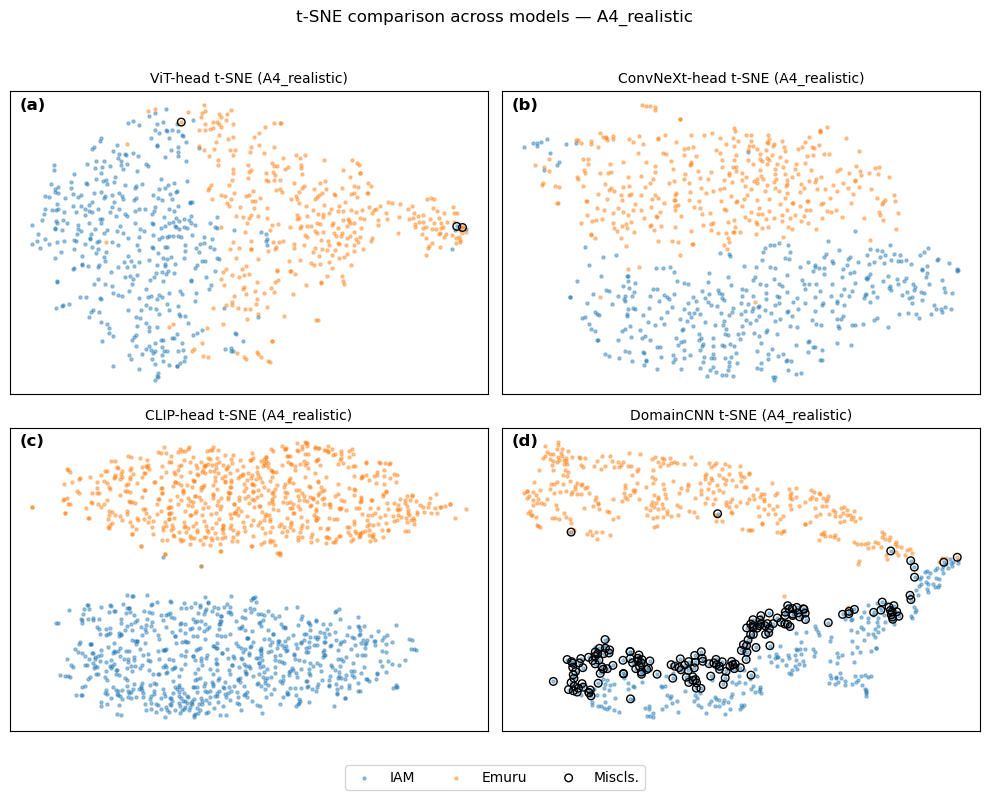

In [5]:
def plot_tsne_ax(ax, df: pd.DataFrame, title: str, panel_label: str):
    iam = (df["true_label"].to_numpy() == 0)
    emu = (df["true_label"].to_numpy() == 1)
    mis = (df["true_label"] != df["pred_label"]).to_numpy()

    ax.scatter(df.loc[iam, "tsne_x"], df.loc[iam, "tsne_y"], s=5, alpha=0.4, label="IAM")
    ax.scatter(df.loc[emu, "tsne_x"], df.loc[emu, "tsne_y"], s=5, alpha=0.4, label="Emuru")

    if mis.any():
        ax.scatter(df.loc[mis, "tsne_x"], df.loc[mis, "tsne_y"],
                   s=30, edgecolors="k", facecolors="none", linewidths=1.0, label="Miscls.")

    # Title and panel label
    ax.set_title(title, fontsize=10)
    ax.text(
        0.02, 0.98, panel_label,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=12, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8, edgecolor="none")
    )

    ax.set_xticks([])
    ax.set_yticks([])

variant = "A4_realistic"  # change: "baseline", "A5_noisy", ...

paths = [
    ("ViT-head", tsne_path_vit(variant)),
    ("ConvNeXt-head", tsne_path_convnext(variant)),
    ("CLIP-head", tsne_path_clip(variant)),
    ("DomainCNN", tsne_path_domaincnn(variant)),
]

panel_labels = ["(a)", "(b)", "(c)", "(d)"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (panel, (name, p)) in zip(axes, zip(panel_labels, paths)):
    if not p.exists():
        ax.set_title(f"{name} (missing)")
        ax.axis("off")
        print("[missing]", p.name)
        continue

    df = load_tsne(p)
    plot_tsne_ax(ax, df, f"{name} t-SNE ({variant})", panel)

# one legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3)

plt.suptitle(f"t-SNE comparison across models — {variant}", y=0.98)
plt.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.show()